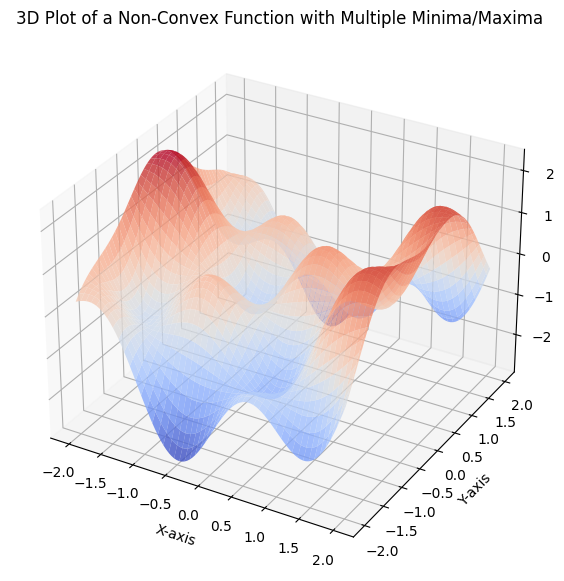

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define a non-convex function with multiple local maxima and minima
def nonconvex_function(x, y):
    return np.sin(3*x) * np.cos(3*y) + 0.5 * (x**2 - y**2)

# Generate grid points
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)
Z = nonconvex_function(X, Y)

# Plot the non-convex function
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.8)
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Function Value')
ax.set_title('3D Plot of a Non-Convex Function with Multiple Minima/Maxima')

plt.show()


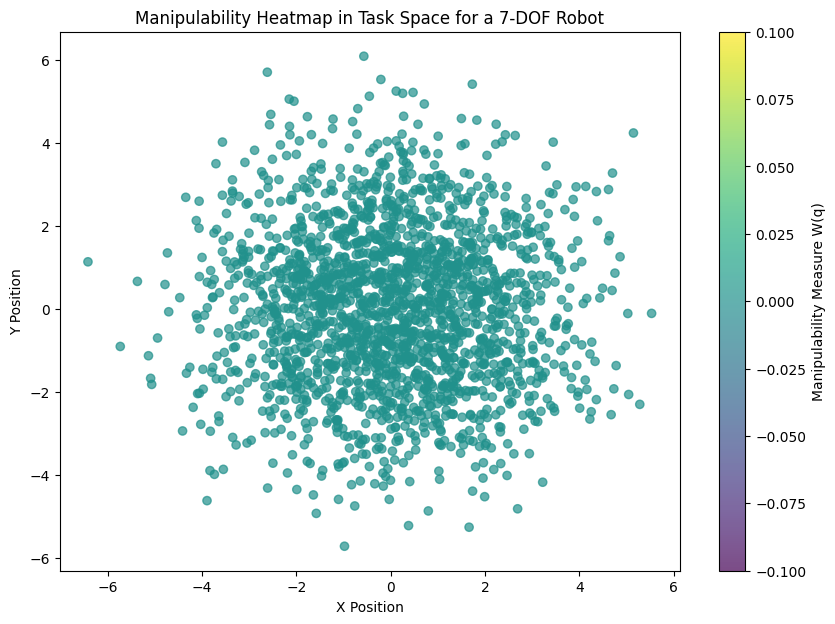

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def random_joint_configurations(num_samples=1000, num_joints=7):
    """Generates random joint configurations within a valid range."""
    return np.random.uniform(low=-np.pi, high=np.pi, size=(num_samples, num_joints))

def forward_kinematics_7dof(q):
    """Computes the forward kinematics to get end-effector position (x, y, z)."""
    # Assume a simple serial chain with 7 links of length 1
    lengths = np.ones(7)
    x = np.sum(lengths * np.cos(np.cumsum(q)))  # Sum of cosines for x
    y = np.sum(lengths * np.sin(np.cumsum(q)))  # Sum of sines for y
    return np.array([x, y, 0])  # 3D Position, but we use (x, y) for heatmap

def compute_jacobian_7dof(q, delta=1e-6):
    """Computes the numerical Jacobian of the 7-DOF arm."""
    num_joints = len(q)
    J = np.zeros((3, num_joints))  # Assuming task space is (x, y, z)
    f_base = forward_kinematics_7dof(q)

    for i in range(num_joints):
        q_perturbed = q.copy()
        q_perturbed[i] += delta
        f_perturbed = forward_kinematics_7dof(q_perturbed)
        J[:, i] = (f_perturbed - f_base) / delta  # Finite difference approximation

    return J

def manipulability_7dof(q):
    """Computes the manipulability measure W(q) = sqrt(det(J * J^T)) for given joint angles."""
    J = compute_jacobian_7dof(q)
    return np.sqrt(np.linalg.det(J @ J.T)) if np.linalg.det(J @ J.T) > 0 else 0  # Avoid sqrt of negative

# Generate random joint configurations
num_samples = 2000
joint_configs = random_joint_configurations(num_samples)

# Compute manipulability for each configuration
manipulability_values = np.array([manipulability_7dof(q) for q in joint_configs])

# Extract (x, y) positions from forward kinematics
xy_positions = np.array([forward_kinematics_7dof(q)[:2] for q in joint_configs])

# Create a heatmap
plt.figure(figsize=(10, 7))
plt.scatter(xy_positions[:, 0], xy_positions[:, 1], c=manipulability_values, cmap='viridis', alpha=0.7)
plt.colorbar(label="Manipulability Measure W(q)")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.title("Manipulability Heatmap in Task Space for a 7-DOF Robot")
plt.show()


In [ ]:
import mujoco
import numpy as np

# Suppose we have a quaternion [qw, qx, qy, qz]
quat = np.array([qw, qx, qy, qz], dtype=np.float64)

# Step 1: Convert Quaternion to 3x3 Rotation Matrix
rot_mat = np.zeros(9, dtype=np.float64)  # MuJoCo stores 3x3 as 9 elements
mujoco.mju_quat2Mat(rot_mat, quat)       # rot_mat now holds a 3x3 rotation in row-major [r00, r01, r02, ..., r20, r21, r22]

# Step 2: Convert Rotation Matrix to Euler Angles
res_euler = np.zeros(3, dtype=np.float64)  # [roll, pitch, yaw]
mujoco.mju_mat2Euler(res_euler, rot_mat)   # Fills res_euler with Euler angles (radians, XYZ order)

print("Euler angles (XYZ):", res_euler)
